In [1]:
import os
import eos
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from wquantiles import quantile_1D

colors = eos.figure.ItemColorCycler()._colors

In [2]:
mpi    = eos.Parameters()["mass::pi^+"].evaluate()
sPlus  = 4 * mpi**2
sMinus = 0.0
sIn    = 0.850509 #pi-omega threshold

In [3]:
analysis_directory = os.getcwd()

fits = [
    (
        'All w/o Belle, N = 6',
        'tau-data-together',
        'FF-fp-I1-order6-without-Belle',
        'C0',
    ),
    (
        'All w/o Belle, N = 8',
        'tau-data-together',
        'FF-fp-I1-order8-without-Belle',
        'C1',
    ),
    (
        'Belle, N = 8',
        'tau-data-seperate',
        'FF-fp-I1-order8-Belle',
        'C2',
    ),
]

Computing KDE for samples of variables 'derived::a11' and 'derived::b11'
Computing KDE for samples of variables 'derived::a11' and 'derived::b11'
Computing KDE for samples of variables 'derived::a11' and 'derived::b11'


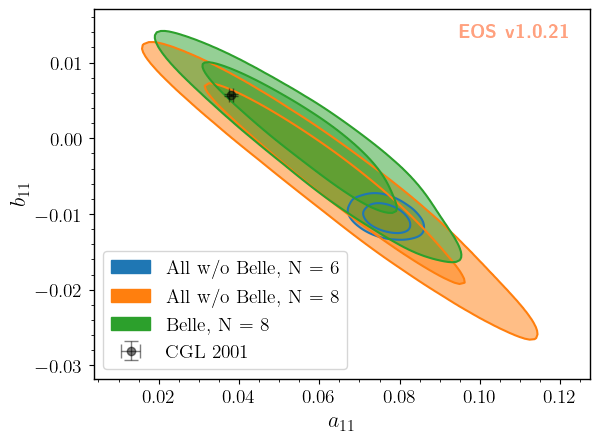

In [4]:
items = []
x_limits = []
y_limits = []

for label, folder, posterior, color in fits:
    samples_path = os.path.join(
        analysis_directory,
        folder,
        'data',
        posterior,
        'scattering-lengths',
        'samples',
    )

    fit = eos.data.ImportanceSamples(samples_path)

    # These saved samples have a11 in column 0 and b11 in column 1.
    a11 = fit.samples[:, 0]
    b11 = fit.samples[:, 1]
    weights = fit.weights

    def local_range(values):
        lower = float(quantile_1D(values, weights, 0.001))
        upper = float(quantile_1D(values, weights, 0.999))
        padding = 0.10 * (upper - lower)
        return [lower - padding, upper + padding]

    a11_range = local_range(a11)
    b11_range = local_range(b11)

    x_limits.append(a11_range)
    y_limits.append(b11_range)

    items.append({
        'type': 'kde2D',
        'label': label,
        'color': color,
        'levels': [68, 95],
        'bandwidth': 2.0,
        'contours': ['lines', 'areas'],
        'datafile': samples_path,
        'variables': ['derived::a11', 'derived::b11'],
        'xrange': a11_range,
        'yrange': b11_range,
    })

# Literature reference on the same a11–b11 plot.
items.append({
    'type': 'errorbars',
    'positions': [[0.0379, 0.00567]],
    'xerrors': [0.0005],
    'yerrors': [0.00013],
    'label': 'CGL 2001',
    'color': 'black',
})

figure_args = {
    'plot': {
        'xaxis': {
            'label': r'$a_{11}$',
            'range': [
                min([bounds[0] for bounds in x_limits] + [0.0379 - 0.0005]),
                max([bounds[1] for bounds in x_limits] + [0.0379 + 0.0005]),
            ],
        },
        'yaxis': {
            'label': r'$b_{11}$',
            'range': [
                min([bounds[0] for bounds in y_limits] + [0.00567 - 0.00013]),
                max([bounds[1] for bounds in y_limits] + [0.00567 + 0.00013]),
            ],
        },
        'legend': {'position': 'lower left'},
        'items': items,
    },
}

figure = eos.figure.FigureFactory.from_dict(**figure_args)
figure.draw()
figure.save('a11vsb11.pdf')
plt.show()

In [8]:
coupling_labels = [
    ("derived::Re{g_rho_gamma}", r"$\mathrm{Re}\,g_{\rho\gamma}$"),
    ("derived::Im{g_rho_gamma}", r"$\mathrm{Im}\,g_{\rho\gamma}$"),
    ("derived::Re{g_rho_pi_pi}", r"$\mathrm{Re}\,g_{\rho\pi\pi}$"),
    ("derived::Im{g_rho_pi_pi}", r"$\mathrm{Im}\,g_{\rho\pi\pi}$"),
]

plot_parameters = eos.Parameters()

for name, latex in coupling_labels:
    if not plot_parameters.has(name):
        plot_parameters.declare_and_insert(
            name, latex, eos.Unit.Unity(),
            0.0, -100.0, 100.0,
        )

Computing KDE for samples of variables 'derived::Re{g_rho_gamma}' and 'derived::Im{g_rho_gamma}'
Computing KDE for samples of variables 'derived::Re{g_rho_gamma}' and 'derived::Im{g_rho_gamma}'
Computing KDE for samples of variables 'derived::Re{g_rho_gamma}' and 'derived::Im{g_rho_gamma}'
Computing KDE for samples of variables 'derived::Re{g_rho_gamma}' and 'derived::Re{g_rho_pi_pi}'
Computing KDE for samples of variables 'derived::Re{g_rho_gamma}' and 'derived::Re{g_rho_pi_pi}'
Computing KDE for samples of variables 'derived::Re{g_rho_gamma}' and 'derived::Re{g_rho_pi_pi}'
Computing KDE for samples of variables 'derived::Im{g_rho_gamma}' and 'derived::Re{g_rho_pi_pi}'
Computing KDE for samples of variables 'derived::Im{g_rho_gamma}' and 'derived::Re{g_rho_pi_pi}'
Computing KDE for samples of variables 'derived::Im{g_rho_gamma}' and 'derived::Re{g_rho_pi_pi}'
Computing KDE for samples of variables 'derived::Re{g_rho_gamma}' and 'derived::Im{g_rho_pi_pi}'
Computing KDE for samples of v

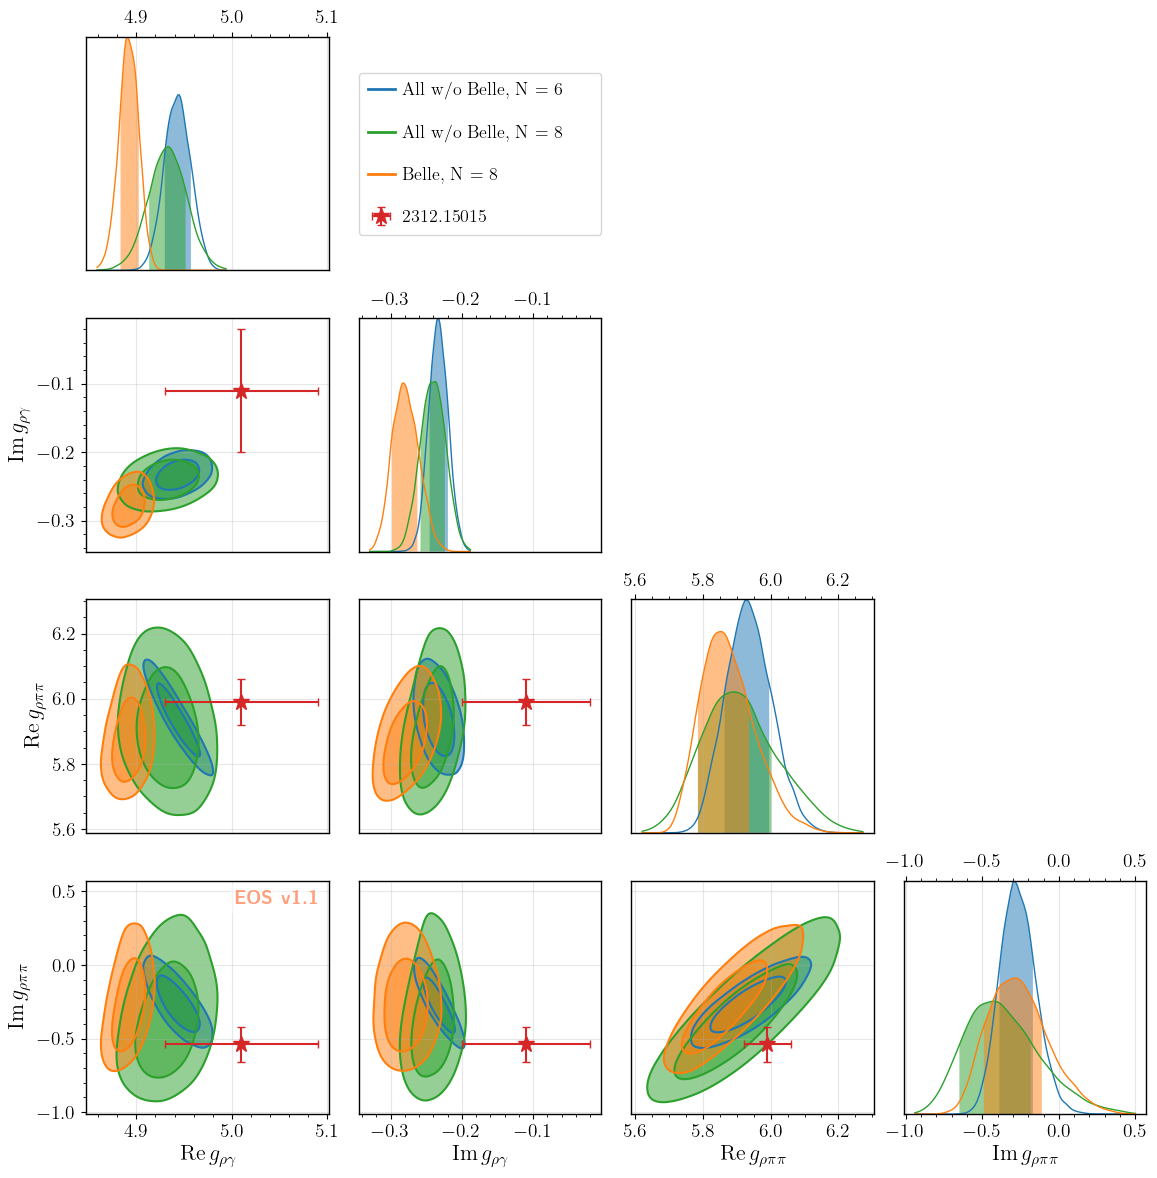

In [21]:
variables = [name for name, _ in coupling_labels]
contents = []

for label, folder, posterior, color in fits:
    samples_path = os.path.join(
        analysis_directory,
        folder,
        'data',
        posterior,
        'rho-couplings',
        'samples',
    )

    samples = eos.data.ImportanceSamples(samples_path)
    sample_variables = [
        entry['name'] for entry in samples.varied_parameters
    ]

    if sample_variables != variables:
        raise ValueError(
            f'{label}: expected {variables}, '
            f'found {sample_variables}'
        )

    contents.append({
        'path': samples_path,
        'label': label,
        'color': color,
        'kde': True,
    })

# Literature values in the same order as variables.
theory = [5.01, -0.11, 5.99, -0.54]
theory_errors = [0.08, 0.09, 0.07, 0.12]

figure = eos.figure.CornerFigure.from_dict(
    contents=contents,
    variables=variables,
    kde=True,
)

figure.prepare()
grid = figure._figure

# Increase smoothing in the 2D KDE panels.
for panel in grid.plots:
    for item in getattr(panel, 'items', []):
        if isinstance(
            item,
            eos.figure.item.TwoDimensionalKernelDensityEstimateItem,
        ):
            item.bandwidth = 2
            item.prepare()

    for attribute in ('xaxis', 'yaxis'):
        axis = getattr(panel, attribute, None)
        if axis is not None and axis.label:
            axis.label = '$' + axis.label.strip().strip('$') + '$'

figure.draw()

size = len(variables)
axes = grid._axes

# Extend the axis ranges to include the literature point and errors.
limits = []

for i in range(size):
    lower, upper = axes[i * size + i].get_xlim()
    lower = min(lower, theory[i] - theory_errors[i])
    upper = max(upper, theory[i] + theory_errors[i])
    padding = 0.05 * (upper - lower)
    limits.append((lower - padding, upper + padding))

theory_handle = None

for i in range(size):
    axes[i * size + i].set_xlim(limits[i])

    for j in range(i):
        ax = axes[i * size + j]

        handle = ax.errorbar(
            theory[j],
            theory[i],
            xerr=theory_errors[j],
            yerr=theory_errors[i],
            fmt='*',
            color='tab:red',
            markersize=12,
            capsize=3,
            zorder=10,
        )

        if theory_handle is None:
            theory_handle = handle

        ax.set_xlim(limits[j])
        ax.set_ylim(limits[i])

legend_handles = [
    Line2D([0], [0], color=color, linewidth=2)
    for _, _, _, color in fits
]
legend_labels = [label for label, _, _, _ in fits]

legend_handles.append(theory_handle)
legend_labels.append('2312.15015')

# Place the legend in the empty top-row cell next to the first plot.
fig = axes[0].figure
legend_cell = axes[1]
cell = legend_cell.get_position()

fig.legend(
    legend_handles,
    legend_labels,
    loc='center',
    bbox_to_anchor=(cell.x0, cell.y0, cell.width, cell.height),
    bbox_transform=fig.transFigure,
    mode='expand',
    borderaxespad=0,
    frameon=True,
    fontsize=13,
    handlelength=1.5,
    handletextpad=0.4,
    labelspacing=1.4,
    borderpad=0.5,
)

figure.save('gcornerplot.pdf')
plt.show()

In [10]:
def plot_ff2_fits(fits, analysis_directory):
    constraint_items = [
         {
                'type': 'constraint',
                'label': 'ALEPH 2013',
                'color': colors[4],
                'variable': 'q2',
                'observable': '0->pipi::Abs{f_+}^2(q2_min,q2_max)',
                'constraints': '0->pipi::Abs{f_+}^2@ALEPH:2013A',
        },
        {
            'type': 'constraint',
            'label': 'Belle 2008',
            'color': colors[0],
            'variable': 'q2',
            'observable': '0->pipi::Abs{f_+}^2(q2_min,q2_max)',
            'constraints': '0->pipi::Abs{f_+}^2@Belle:2008C',
        },
        {
            'type': 'constraint',
            'label': 'CLEO 2000',
            'color': colors[1],
            'variable': 'q2',
            'observable': '0->pipi::Abs{f_+}^2(q2_min,q2_max)',
            'constraints': '0->pipi::Abs{f_+}^2@CLEO:2000B',
        },
        {
            'type': 'constraint',
            'label': 'OPAL 1999',
            'color': colors[5],
            'variable': 'q2',
            'observable': '0->pipi::Abs{f_+}^2(q2_min,q2_max)',
            'constraints': '0->pipi::Abs{f_+}^2@OPAL:1999A',
        },
        {
            'type': 'constraint',
            'label': 'NA7 1986',
            'color': colors[8],
            'variable': 'q2',
            'observable': '0->pipi::Abs{f_+}^2(q2)',
            'constraints': '0->pipi::Abs{f_+}^2@NA7:1986A',
        },
    ]

    figures = {}

    for label, folder, posterior, _ in fits:
        prediction_file = os.path.join(
            analysis_directory,
            folder,
            'data',
            posterior,
            'pred-FF-fp2-I1-all',
        )
        if not os.path.isdir(prediction_file):
            raise FileNotFoundError(prediction_file)

        fit_item = {
            'type': 'uncertainty',
            'label': label,
            'color': 'C2',
            'alpha': 0.25,
            'variable': 'q2',
            'range': [-1.2, 2.0],
            'interpolation': 'cubic',
            'resolution': 300,
            'datafile': prediction_file,
        }

        main_items = constraint_items + [
            fit_item,
            {
                'type': 'band',
                'color': 'gray',
                'alpha': 0.25,
                'x': [sIn, 2.0],
                'y': [0.1, 100.0],
            },
        ]

        inset_fit_item = {
            **fit_item,
            'range': [0.4, 0.8],
            'resolution': 600,
        }
        inset_items = constraint_items + [inset_fit_item]

        figure = eos.figure.InsetFigure.from_dict(
            size=[10, 7],
            watermark={'position': 'lower right'},
            plot={
                'title': label,
                'xaxis': {
                    'label': '$s$',
                    'unit': '$\\mathrm{GeV}^2$',
                    'range': [-1.2, 2.0],
                },
                'yaxis': {
                    'label': r'$|F_\pi|^2$',
                    'range': [0.1, 100.0],
                    'scale': 'log',
                },
                'legend': {'position': 'upper left'},
                'items': main_items,
            },
            inset={
                'position': [0.65, 0.7],  # left, bottom
                'size': [0.38, 0.32],      # width, height
                'plot': {
                'xaxis': {'range': [0.4, 0.8]},
                'yaxis': {
                'range': [10.0, 60.0],
                'scale': 'log',
                },
                'items': inset_items,},
            },
        )

        figure.draw()
        figures[posterior] = figure
        plt.show()

    return figures

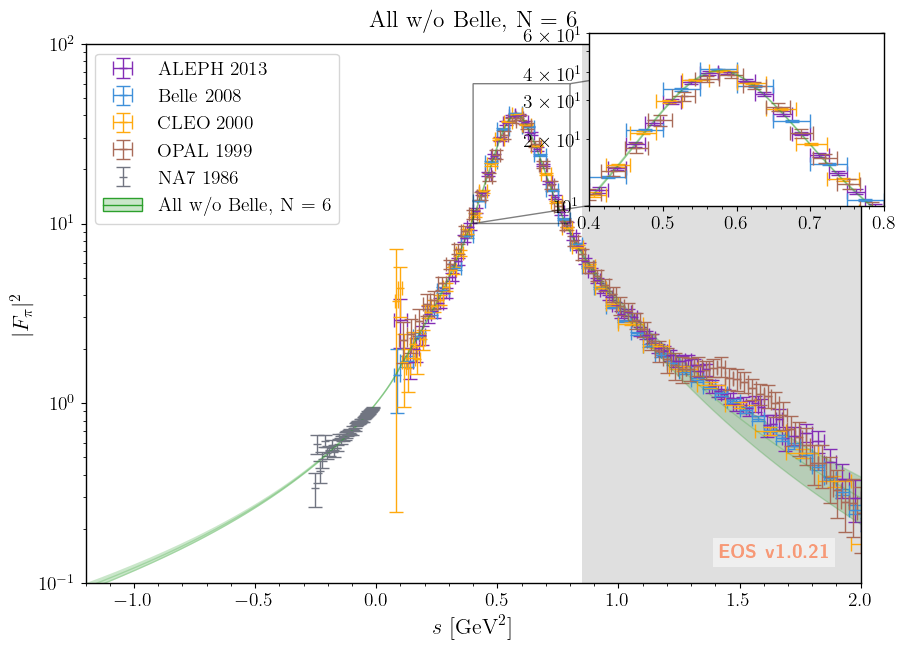

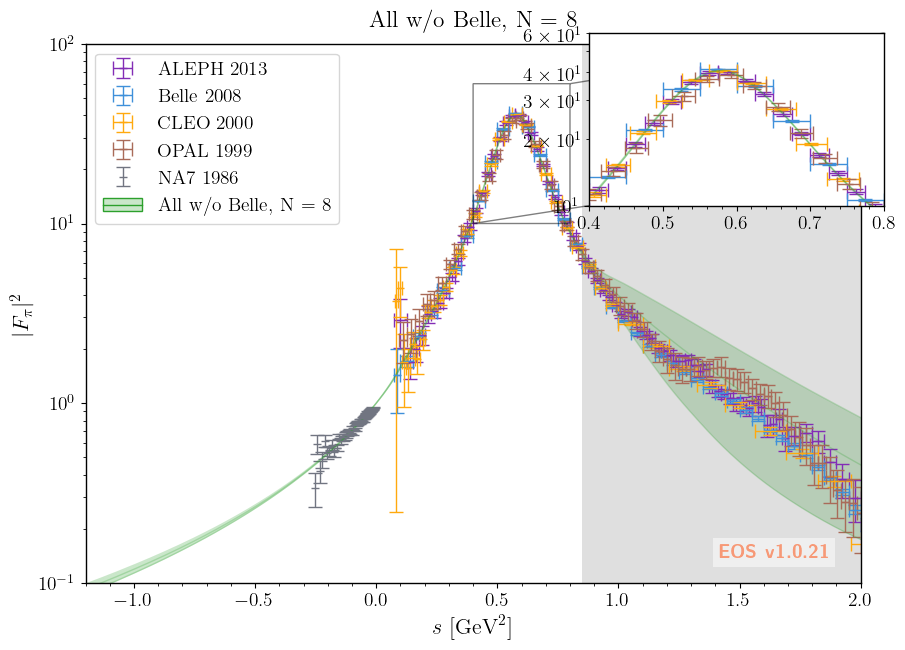

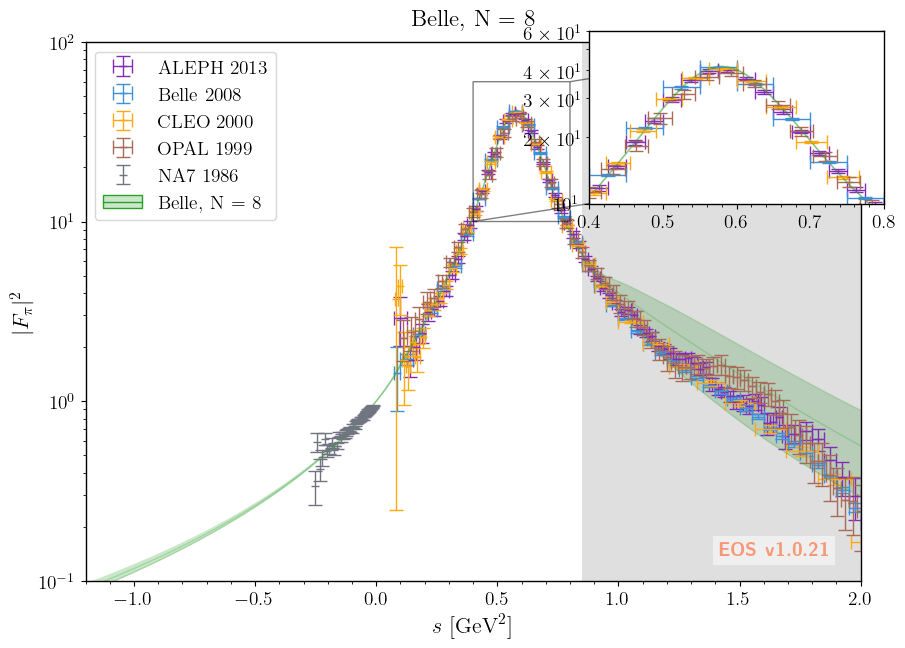

In [11]:
ff_figures = plot_ff2_fits(fits, analysis_directory)

In [7]:
def plot_t11_fits(fits, analysis_directory):
    figures = {}

    for label, folder, posterior, _ in fits:
        fit_directory = os.path.join(
            analysis_directory, folder, 'data', posterior
        )
        real_path = os.path.join(
            fit_directory, 'pred-real-partial-wave-I1'
        )
        imag_path = os.path.join(
            fit_directory, 'pred-imag-partial-wave-I1'
        )

        for path in (real_path, imag_path):
            if not os.path.isdir(path):
                raise FileNotFoundError(path)

        real_item = {
            'type': 'uncertainty',
            'label': 'real part',
            'color': 'tab:blue',
            'variable': 'q2',
            'interpolation': 'cubic',
            'resolution': 250,
            'datafile': real_path,
        }
        imag_item = {
            'type': 'uncertainty',
            'label': 'imag part',
            'color': 'tab:purple',
            'variable': 'q2',
            'interpolation': 'cubic',
            'resolution': 250,
            'datafile': imag_path,
        }

        inset_items = [
            {
                **real_item,
                'range': [-sPlus, 0.1],
                'resolution': 3000,
            },
            {
                **imag_item,
                'range': [-sPlus, 0.1],
                'resolution': 3000,
            },
            {
                'type': 'expression',
                'expression': '0',
                'range': [-sPlus, 0.1],
                'color': 'k',
            },
            {
                'type': 'vertical',
                'x': 0.0,
                'color': 'k',
                'alpha': 1.0,
                'linewidth': 1.0,
            },
            {
                'type': 'vertical',
                'x': sPlus,
                'color': 'k',
                'alpha': 1.0,
                'linestyle': 'dotted',
                'linewidth': 1.0,
                'label': r'$s_+$',
            },
        ]

        figure = eos.figure.InsetFigure.from_dict(
            size=[10, 7],
            watermark={'position': 'lower right'},
            plot={
                'title': label,
                'xaxis': {
                    'label': '$s$',
                    'unit': '$\\mathrm{GeV}^2$',
                    'range': [-2.5, 2.5],
                },
                'yaxis': {
                    'label': '$t_1^1$',
                    'range': [-0.7, 1.1],
                },
                'legend': {'position': 'upper left'},
                'items': [real_item, imag_item],
            },
            inset={
                'position': [-0.05, 0.0],
                'size': [0.38, 0.32],
                'plot': {
                    'xaxis': {'range': [-sPlus, 0.1]},
                    'yaxis': {'range': [-0.5, 0.5]},
                    'items': inset_items,
                },
            },
        )

        figure.draw()
        figures[posterior] = figure
        plt.show()

    return figures

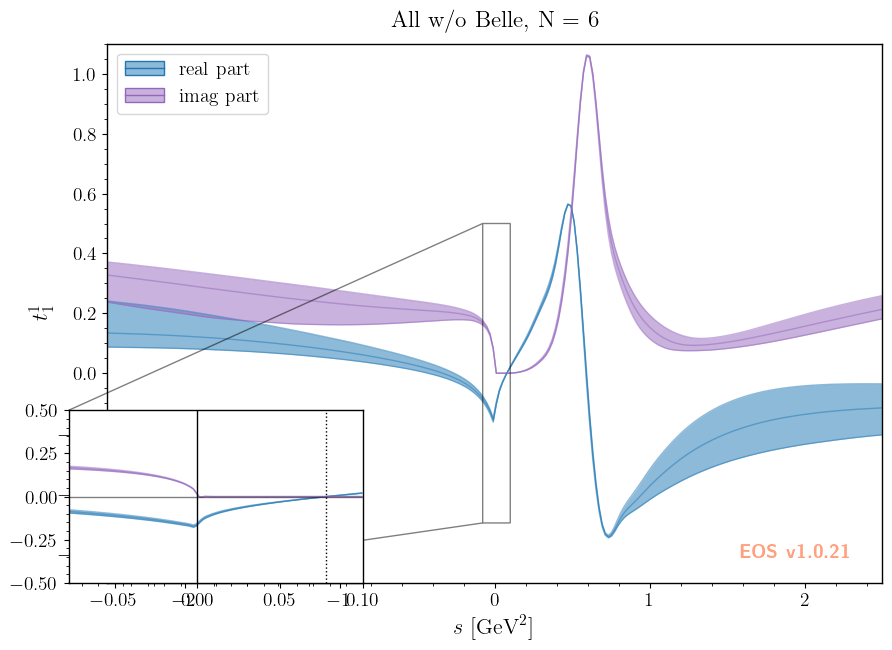

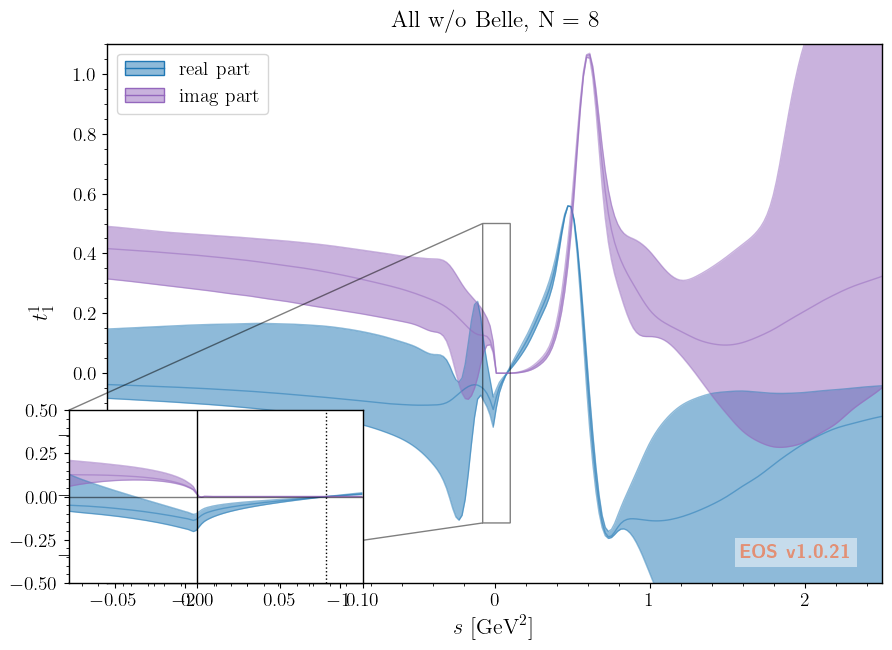

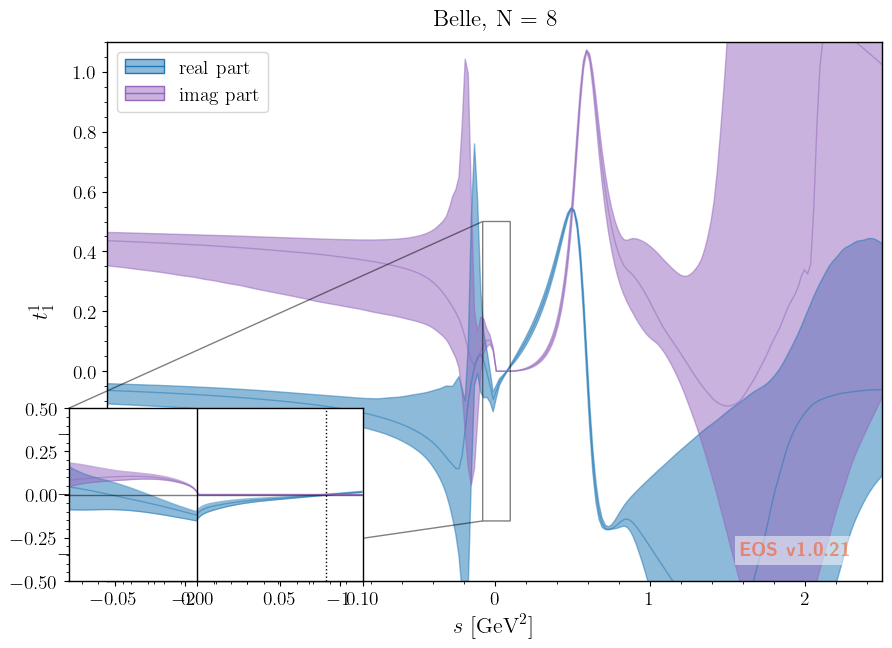

In [8]:
t11_figures = plot_t11_fits(fits, analysis_directory)

Creating analysis with 5 priors, 4 EOS-wide constraints, 2 global options, 2 manually-entered constraints and 2 fixed parameters.
likelihood probably depends on 21 parameter(s) that do not appear in the prior; check prior?


Residuals at the saved best-fit point: All w/o Belle, N = 6


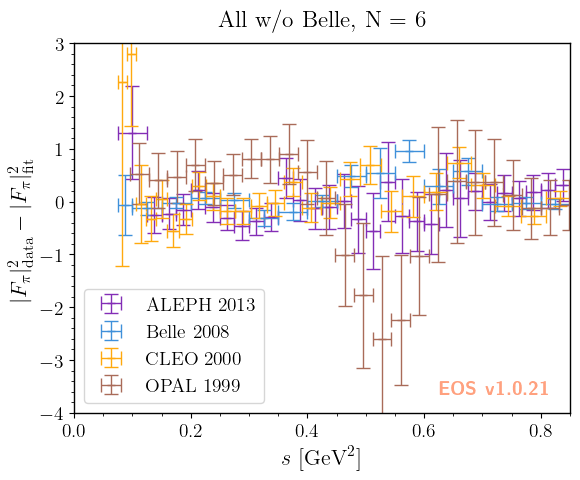

Creating analysis with 7 priors, 4 EOS-wide constraints, 2 global options, 2 manually-entered constraints and 2 fixed parameters.
likelihood probably depends on 19 parameter(s) that do not appear in the prior; check prior?


Residuals at the saved best-fit point: All w/o Belle, N = 8


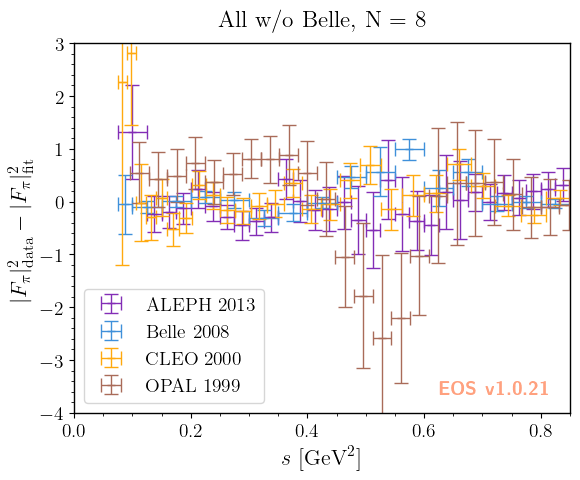

Creating analysis with 1 priors, 2 EOS-wide constraints, 2 global options, 2 manually-entered constraints and 2 fixed parameters.
likelihood probably depends on 19 parameter(s) that do not appear in the prior; check prior?


Residuals at the saved best-fit point: Belle, N = 8


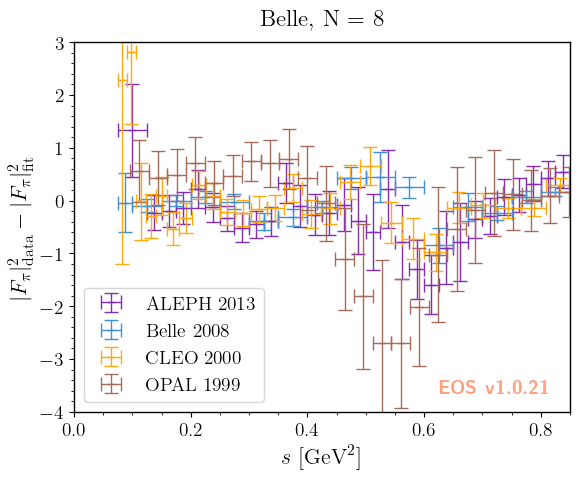

In [9]:
residue_datasets = [
    ("ALEPH 2013", "0->pipi::Abs{f_+}^2@ALEPH:2013A", colors[4]),
    ("Belle 2008", "0->pipi::Abs{f_+}^2@Belle:2008C", colors[0]),
    ("CLEO 2000",  "0->pipi::Abs{f_+}^2@CLEO:2000B", colors[1]),
    ("OPAL 1999",  "0->pipi::Abs{f_+}^2@OPAL:1999A", colors[5]),
]

def plot_residues_for_fit(label, folder, posterior):
    fit_directory = os.path.join(analysis_directory, folder)
    analysis_file = eos.AnalysisFile(
        os.path.join(fit_directory, "analysis.yaml")
    )
    analysis = analysis_file.analysis(posterior)

    mode = eos.data.Mode(
        os.path.join(fit_directory, "data", posterior, "mode-default")
    )

    # Start with all parameters, including fixed ones, then insert
    # the saved best-fit values for the varied parameters.
    param_dict = {
        parameter.name(): parameter.evaluate()
        for parameter in analysis.parameters
    }
    for parameter, value in zip(analysis.varied_parameters, mode.mode):
        param_dict[parameter.name()] = float(value)

    fit_options = dict(analysis.init_args.get("global_options") or {})
    fit_options.setdefault("form-factors", "BHKMNR2026")

    items = [
        {
            "type": "constraint-residue",
            "label": dataset_label,
            "parameters": param_dict,
            "options": fit_options,
            "color": color,
            "variable": "q2",
            "observable": "0->pipi::Abs{f_+}^2(q2_min,q2_max)",
            "style": "delta",
            "constraints": constraint,
        }
        for dataset_label, constraint, color in residue_datasets
    ]

    figure_args = {
        "watermark": {"position": "lower right"},
        "plot": {
            "title": label,
            "xaxis": {
                "label": r"$s$",
                "unit": r"$\mathrm{GeV}^2$",
                "range": [0.0, sIn],
            },
            "yaxis": {
                "label": (
                    r"$|F_\pi|^2_{\mathrm{data}}"
                    r" - |F_\pi|^2_{\mathrm{fit}}$"
                ),
                "range": [-4, 3],
                "scale": "linear",
            },
            "legend": {"position": "lower left"},
            "items": items,
        },
    }

    print(f"Residuals at the saved best-fit point: {label}")
    figure = eos.figure.FigureFactory.from_dict(**figure_args)
    figure.draw()
    plt.show()
    return figure


residue_figures = {}

for label, folder, posterior, _fit_color in fits:
    residue_figures[label] = plot_residues_for_fit(
        label, folder, posterior
    )

Computing KDE for samples of variables '0->pipi::M_(+,1,0)@BHKMNR2026' and '0->pipi::Gamma_(+,1,0)@BHKMNR2026'


Computing KDE for samples of variables '0->pipi::M_(+,1,0)@BHKMNR2026' and '0->pipi::Gamma_(+,1,0)@BHKMNR2026'
Computing KDE for samples of variables '0->pipi::M_(+,1,0)@BHKMNR2026' and '0->pipi::Gamma_(+,1,0)@BHKMNR2026'


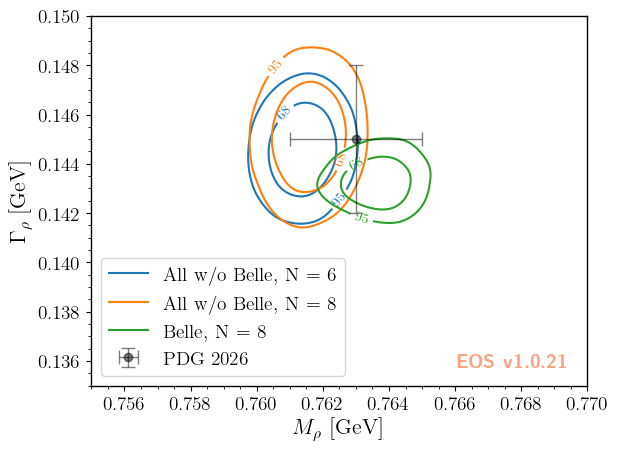

In [13]:
mass_gamma_items = [
    {
        "type": "kde2D",
        "label": label,
        "color": color,
        "levels": [68, 95],
        "contours": ["lines", "labels"],
        "bandwidth": 2.0,
        "datafile": os.path.join(
            analysis_directory, folder, "data", posterior, "samples"
        ),
        "variables": [
            "0->pipi::M_(+,1,0)@BHKMNR2026",
            "0->pipi::Gamma_(+,1,0)@BHKMNR2026",
        ],
    }
    for label, folder, posterior, color in fits
]

mass_gamma_items.append({
    "type": "errorbars",
    "positions": [[0.763, 0.145]],
    "xerrors": [0.002],
    "yerrors": [0.003],
    "label": "PDG 2026",
    "color": "black",
})

figure_args = {
    "watermark": {"position": "lower right"},
    "plot": {
        "xaxis": {
            "label": r"$M_\rho$",
            "unit": r"$\mathrm{GeV}$",
            "range": [0.755, 0.77],
        },
        "yaxis": {
            "label": r"$\Gamma_\rho$",
            "unit": r"$\mathrm{GeV}$",
            "range": [0.135, 0.15],
        },
        "legend": {"position": "lower left"},
        "items": mass_gamma_items,
    },
}

figure = eos.figure.FigureFactory.from_dict(**figure_args)
figure.draw()